In [1]:
from scipy import stats
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
import os

FOLD CHANGE ANALYSIS: ΔrhlA / WT
Comparing: 0-10 µm vs 10-20 µm

0-10 µm:
  WT mean:       0.0001 (0.01%)
  ΔrhlA mean:    0.0197 (1.97%)
  Fold change:   145.02×
  p-value:       0.0000 ***

10-20 µm:
  WT mean:       0.0124 (1.24%)
  ΔrhlA mean:    0.0475 (4.75%)
  Fold change:   3.83×
  p-value:       0.0000 ***


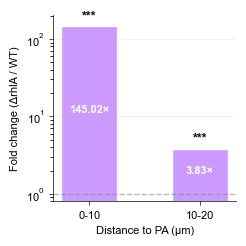


SUMMARY TABLE
  Bin  WT_mean  rhlA_mean  Fold_change significance
 0-10 0.000136   0.019745   145.016946          ***
10-20 0.012390   0.047483     3.832211          ***

KEY FINDINGS

ΔrhlA survival enhancement:
  Close distance (0-10 µm):  145.02× higher than WT
  Far distance (10-20 µm):   3.83× higher than WT

The enhancement at close distances is 37.84× stronger
This represents a 3684% reduction in fold change at far distances

FILE SAVED: S5_fold_change_wt_∆rhlA.pdf


In [2]:
# Set Arial font
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42

# =============================================================================
# LOAD DATA - Only WT and ΔrhlA
# =============================================================================
regrowth_chamber_wt = pd.read_csv('../Figure1/1E/figure_code/1_regrowth_fractions_wt_per_chamber.csv')
regrowth_chamber_rhlA = pd.read_csv('../Figure2/2AB/analysis_code/2A_rhlA/figure_code/4_regrowth_fractions_rhlA_per_chamber.csv')

# Add strain labels
regrowth_chamber_wt['strain'] = 'WT'
regrowth_chamber_rhlA['strain'] = 'ΔrhlA'

# Combine datasets
all_data = pd.concat([regrowth_chamber_wt, regrowth_chamber_rhlA], ignore_index=True)

# Filter for y-axis data only
y_data = all_data[all_data['axis'] == 'y'].copy()

print("="*70)
print("FOLD CHANGE ANALYSIS: ΔrhlA / WT")
print("Comparing: 0-10 µm vs 10-20 µm")
print("="*70)

# =============================================================================
# CREATE BINS
# =============================================================================
analysis_data_list = []

# 0-10 µm (aggregate bins 0 and 5)
bin_0_10 = y_data[y_data['bin_left'].isin([0, 5])].copy()
bin_0_10_agg = bin_0_10.groupby(['strain', 'replicate', 'position'])['regrowth_fraction'].mean().reset_index()
bin_0_10_agg['bin_label'] = '0-10'
analysis_data_list.append(bin_0_10_agg)

# 10-20 µm (aggregate bins 10 and 15)
bin_10_20 = y_data[y_data['bin_left'].isin([10, 15])].copy()
bin_10_20_agg = bin_10_20.groupby(['strain', 'replicate', 'position'])['regrowth_fraction'].mean().reset_index()
bin_10_20_agg['bin_label'] = '10-20'
analysis_data_list.append(bin_10_20_agg)

# Combine all bins
analysis_data = pd.concat(analysis_data_list, ignore_index=True)

# =============================================================================
# CALCULATE FOLD CHANGE FOR EACH BIN
# =============================================================================
bins_to_analyze = ['0-10', '10-20']
fold_change_data = []

for bin_label in bins_to_analyze:
    bin_data = analysis_data[analysis_data['bin_label'] == bin_label]
    
    # Get data for each strain
    wt_values = bin_data[bin_data['strain'] == 'WT']['regrowth_fraction'].values
    rhlA_values = bin_data[bin_data['strain'] == 'ΔrhlA']['regrowth_fraction'].values
    
    # Calculate means
    wt_mean = np.mean(wt_values)
    rhlA_mean = np.mean(rhlA_values)
    
    # Fold change
    if wt_mean > 0:
        fold_change = rhlA_mean / wt_mean
    else:
        fold_change = np.nan
    
    # Statistical test
    u_stat, p_value = stats.mannwhitneyu(wt_values, rhlA_values, alternative='two-sided')
    
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        sig = "ns"
    
    fold_change_data.append({
        'Bin': bin_label,
        'WT_mean': wt_mean,
        'rhlA_mean': rhlA_mean,
        'Fold_change': fold_change,
        'p_value': p_value,
        'significance': sig
    })
    
    print(f"\n{bin_label} µm:")
    print(f"  WT mean:       {wt_mean:.4f} ({wt_mean*100:.2f}%)")
    print(f"  ΔrhlA mean:    {rhlA_mean:.4f} ({rhlA_mean*100:.2f}%)")
    if not np.isnan(fold_change):
        print(f"  Fold change:   {fold_change:.2f}×")
    else:
        print(f"  Fold change:   Cannot calculate (WT ≈ 0)")
    print(f"  p-value:       {p_value:.4f} {sig}")

results_df = pd.DataFrame(fold_change_data)

# =============================================================================
# BAR PLOT WITH LOG SCALE
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))

# Extract data
bins = results_df['Bin'].values
fold_changes = results_df['Fold_change'].values
x_positions = np.arange(len(bins))

# Create bars
bars = ax.bar(x_positions, fold_changes, width=0.5, 
              color='#cc99ff', edgecolor='white', linewidth=1)

# Set LOG SCALE
ax.set_yscale('log')

# Add horizontal line at fold change = 1 (no difference)
ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Add fold change values INSIDE bars (geometric center for log scale)
for i, fold in enumerate(fold_changes):
    if not np.isnan(fold):
        y_pos = np.sqrt(fold)  # Geometric mean between 1 and fold_change
        ax.text(i, y_pos, f'{fold:.2f}×', ha='center', va='center', 
                fontsize=8, fontweight='bold', color='white')

# Add significance stars above bars
for i, (fold, sig) in enumerate(zip(fold_changes, results_df['significance'])):
    if sig != 'ns' and not np.isnan(fold):
        ax.text(i, fold * 1.15, sig, ha='center', va='bottom', 
                fontsize=9, fontweight='bold')

# Customize
ax.set_xticks(x_positions)
ax.set_xticklabels(bins, fontsize=8)
ax.set_xlabel('Distance to PA (µm)', fontsize=8)
ax.set_ylabel('Fold change (ΔrhlA / WT)', fontsize=8)

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(width=0.5, length=3, labelsize=8)
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5, which='major')

# Set y-axis limits for log scale
valid_fcs = [fc for fc in fold_changes if not np.isnan(fc)]
if valid_fcs:
    ax.set_ylim(0.8, max(valid_fcs) * 1.4)

plt.tight_layout()
plt.savefig('S5_fold_change_wt_∆rhlA.pdf', bbox_inches='tight')
plt.show()

# =============================================================================
# SUMMARY
# =============================================================================
print(f"\n{'='*70}")
print("SUMMARY TABLE")
print(f"{'='*70}")
print(results_df[['Bin', 'WT_mean', 'rhlA_mean', 'Fold_change', 'significance']].to_string(index=False))

print(f"\n{'='*70}")
print("KEY FINDINGS")
print(f"{'='*70}")

fc_0_10 = results_df[results_df['Bin'] == '0-10']['Fold_change'].values[0]
fc_10_20 = results_df[results_df['Bin'] == '10-20']['Fold_change'].values[0]

print(f"\nΔrhlA survival enhancement:")
print(f"  Close distance (0-10 µm):  {fc_0_10:.2f}× higher than WT")
print(f"  Far distance (10-20 µm):   {fc_10_20:.2f}× higher than WT")
print(f"\nThe enhancement at close distances is {fc_0_10/fc_10_20:.2f}× stronger")
print(f"This represents a {((fc_0_10 - fc_10_20) / fc_10_20 * 100):.0f}% reduction in fold change at far distances")

print(f"\n{'='*70}")
print("FILE SAVED: S5_fold_change_wt_∆rhlA.pdf")
print(f"{'='*70}")
